In [2]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)


IN_consensus = '../IN/data/in.consensus.reduce4.seq'
# IN_consensus = '../IN/data/in.nl43.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'

IN_nl43 = '../IN/data/in.nl43.reduce4.seq'
with open(IN_nl43, 'r') as f:
    IN_nl43_seq = f.read().strip()

IN_consensus_seq = IN_nl43_seq  # Set the consensus sequence to the NL43 sequence

with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')

In [3]:
de_dict = {}
for position in range (1,263+1):
    wt = IN_consensus_seq[position-1]
    for aa_reduced1 in ['A','B','C','D']:
        if aa_reduced1 == wt:
            continue
        pair1_reduced = wt + str(position)+ aa_reduced1
        de = functions.calculate_delta_e(pair1_reduced,IN_consensus_seq,IN_J,1,263)
        de_dict[pair1_reduced] = de
        if de > -1:
            print(f"IN: {pair1_reduced} -> ΔE = {de}")
# print(de_dict['C140D']+de_dict['D148B']+8.508784)
print(functions.calculate_dde_v2('C140D','D148B',IN_consensus_seq,IN_J,1,263))

IN: D72A -> ΔE = 1.2664785385131836
IN: D113C -> ΔE = 3.203610420227051
IN: C124A -> ΔE = -0.42915868759155273
IN: D125A -> ΔE = -0.6963024139404297
IN: B151A -> ΔE = 2.0166234970092773
IN: A155C -> ΔE = 1.382767677307129
IN: B201A -> ΔE = -0.34204673767089844
IN: A234C -> ΔE = 4.314117431640625
IN: A234D -> ΔE = 1.3409080505371094
(np.float32(-6.7059155), np.float32(-4.577813), np.float32(-2.7749462), np.float32(8.508782))


In [4]:
de_dict_uv = {}
uv = 0.001
for position in range (1,263+1):
    wt = IN_consensus_seq[position-1]
    for aa_reduced1 in ['A','B','C','D']:
        if aa_reduced1 == wt:
            continue
        if functions.calculate_freq(aa_reduced1, position, IN_all_seq) < uv:
            continue
        pair1_reduced = wt + str(position)+ aa_reduced1
        de = functions.calculate_delta_e(pair1_reduced,IN_consensus_seq,IN_J,1,263)
        de_dict_uv[pair1_reduced] = de
        if de > -1:
            print(f"IN: {pair1_reduced} -> ΔE = {de}")
# print(de_dict_uv['C140D']+de_dict_uv['D148B']+8.508784)
print(functions.calculate_dde_v2('C140D','D148B',IN_consensus_seq,IN_J,1,263))

IN: D72A -> ΔE = 1.2664785385131836
IN: D113C -> ΔE = 3.203610420227051
IN: C124A -> ΔE = -0.42915868759155273
IN: D125A -> ΔE = -0.6963024139404297
IN: B151A -> ΔE = 2.0166234970092773
IN: A155C -> ΔE = 1.382767677307129
IN: B201A -> ΔE = -0.34204673767089844
IN: A234C -> ΔE = 4.314117431640625
IN: A234D -> ΔE = 1.3409080505371094
(np.float32(-6.7059155), np.float32(-4.577813), np.float32(-2.7749462), np.float32(8.508782))


In [5]:
# Print sequence differences between IN_consensus_seq and IN_nl43_seq
if len(IN_consensus_seq) != len(IN_nl43_seq):
    print(f"Length mismatch: consensus={len(IN_consensus_seq)} nl43={len(IN_nl43_seq)}")
else:
    diffs = [(i+1, c, n) for i, (c, n) in enumerate(zip(IN_consensus_seq, IN_nl43_seq)) if c != n]
    print(f"Total differences: {len(diffs)}")
    for pos, cons, nl43 in diffs:
        print(f"{pos}: {cons} -> {nl43}")

Total differences: 0


In [6]:
functions.unreduced_to_reduced(IN_redux,'N155H')

'A155C'

In [11]:
dE_NL43 = functions.calculate_delta_e('D148B',IN_consensus_seq,IN_J,1,263) - functions.calculate_delta_e('D148B',IN_nl43_seq,IN_J,1,263)
print(functions.calculate_delta_e('D148B',IN_consensus_seq,IN_J,1,263))
print(functions.calculate_delta_e('D148B',IN_nl43_seq,IN_J,1,263))
print(f"ΔE for nl43 between consensus and NL43: {dE_NL43}")

dE_NL43 = functions.calculate_delta_e('C140D',IN_consensus_seq,IN_J,1,263) - functions.calculate_delta_e('C140D',IN_nl43_seq,IN_J,1,263)
print(functions.calculate_delta_e('C140D',IN_consensus_seq,IN_J,1,263))
print(functions.calculate_delta_e('C140D',IN_nl43_seq,IN_J,1,263))
print(f"ΔE for nl43 between consensus and NL43: {dE_NL43}")


dE_NL43 = functions.calculate_delta_e('A155C',IN_consensus_seq,IN_J,1,263) - functions.calculate_delta_e('A155C',IN_nl43_seq,IN_J,1,263)
print(functions.calculate_delta_e('A155C',IN_consensus_seq,IN_J,1,263))
print(functions.calculate_delta_e('A155C',IN_nl43_seq,IN_J,1,263))
print(f"ΔE for nl43 between consensus and NL43: {dE_NL43}")

E_consensus = functions.calculate_e(IN_consensus_seq, IN_J, 1, 263)
E_nl43 = functions.calculate_e(IN_nl43_seq, IN_J, 1, 263)
print(f"Energy of consensus sequence: {E_consensus}")
print(f"Energy of NL43 sequence: {E_nl43}")
dE_nl43 =  E_consensus - E_nl43
print(f"Total ΔE for nl43 between consensus and NL43: {dE_nl43}")

-4.577813
-4.577813
ΔE for nl43 between consensus and NL43: 0.0
-6.7059155
-6.7059155
ΔE for nl43 between consensus and NL43: 0.0
1.3827677
1.3827677
ΔE for nl43 between consensus and NL43: 0.0
Energy of consensus sequence: -1545.5013427734375
Energy of NL43 sequence: -1545.5013427734375
Total ΔE for nl43 between consensus and NL43: 0.0


DRM: N155H -> ΔE = 1.382767677307129
DRM: T66A -> ΔE = -11.079068183898926
DRM: Y143H -> ΔE = -9.916910171508789
DRM: T66K -> ΔE = -9.199591636657715
DRM: G140C -> ΔE = -9.047880172729492
DRM: H51Y -> ΔE = -8.323115348815918
DRM: Y143C -> ΔE = -8.272261619567871
DRM: S153Y -> ΔE = -8.232246398925781
DRM: Q148K -> ΔE = -7.578909873962402
DRM: G140A -> ΔE = -7.272866725921631
DRM: R263K -> ΔE = -7.223257064819336
DRM: F121Y -> ΔE = -7.068692207336426
DRM: G140S -> ΔE = -6.705915451049805
DRM: T66I -> ΔE = -5.80064582824707
DRM: Y143R -> ΔE = -5.760201454162598
DRM: S147G -> ΔE = -4.937301158905029
DRM: Q148H -> ΔE = -4.577813148498535
DRM: Q148R -> ΔE = -4.038245677947998
DRM: T97A -> ΔE = -3.8361129760742188
DRM: E92Q -> ΔE = -2.9859352111816406
DRM: N155H -> ΔE = 1.382767677307129
Annotating DRM: H51Y at ΔE = -8.323115348815918 with label level y = -0.15
Annotating DRM: T66A at ΔE = -11.079068183898926 with label level y = -0.22999999999999998
Annotating DRM: T66I at ΔE = -5.8006458282

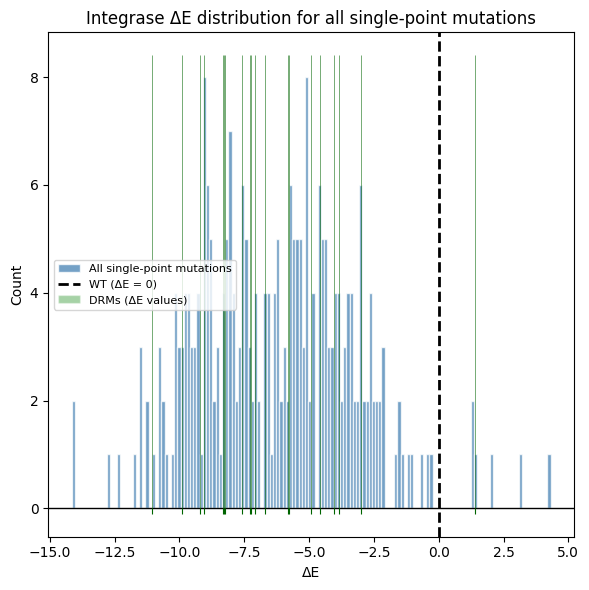

In [8]:
import numpy as np

import matplotlib.pyplot as plt

from ms0_5.IN.data.primary_accessory_mutations import IN_primary_mutations, IN_accessory_mutations
from pathlib import Path

# TODO
# all_de = np.array(list(de_dict.values()), dtype=float)
all_de = np.array(list(de_dict_uv.values()), dtype=float)

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(all_de, bins=150, color="steelblue", alpha=0.75, edgecolor="white", label="All single-point mutations")

# Wild-type reference
ax.axvline(0, color="black", linestyle="--", linewidth=2, label="WT (ΔE = 0)")

# Optional DRM overlay if a DRM mutation list is available in the notebook
drm_vars = ["IN_DRMs", "IN_DRM_mutations", "IN_drm_mutations", "IN_drm_list", "DRMs"]
drm_mutations = IN_primary_mutations
for var_name in drm_vars:
    if var_name in globals():
        drm_mutations = globals()[var_name]
        break

if drm_mutations is not None:
    if isinstance(drm_mutations, dict):
        drm_mutations = list(drm_mutations.keys())

    drm_records = []
    for drm_mut in drm_mutations:
        drm_mut_reduced = functions.unreduced_to_reduced(IN_redux, drm_mut)
        drm_mut_unreduced = functions.reduced_to_unreduced(IN_redux, drm_mut_reduced,IN_all_seq_unreduced,1)
        # print(f"DRM: {drm_mut_unreduced}")
        if drm_mut != drm_mut_unreduced:
            print(f"Warning: DRM mutation {drm_mut} does not match its unreduced form {drm_mut_unreduced}. Skipping.")
            continue
        try:
            # drm_de = float(functions.calculate_delta_e(drm_mut_reduced, IN_consensus_seq, IN_J, 1, 263))
            drm_de = float(functions.calculate_delta_e(drm_mut_reduced, IN_consensus_seq, IN_J, 1, 263))
            if drm_de > -1:
                print(f"DRM: {drm_mut} -> ΔE = {drm_de}")
            drm_records.append((drm_mut, drm_de))
        except Exception:
            pass
    for drm_mut, drm_de in sorted(drm_records, key=lambda x: x[1]):
        print(f"DRM: {drm_mut} -> ΔE = {drm_de}")

    if len(drm_records) > 0:
        drm_vals = np.array([de for _, de in drm_records], dtype=float)
        counts, bin_edges = np.histogram(drm_vals, bins=60)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        # mirrored_log_counts = -np.log10(counts + 1)

        ax.bar(
            bin_centers,
            # mirrored_log_counts,
            counts,
            width=np.diff(bin_edges),
            color="green",
            alpha=0.35,
            edgecolor="white",
            align="center",
            label="DRMs (ΔE values)",
        )

        ax.axhline(0, color="black", linewidth=1)

        # y_min = float(mirrored_log_counts.min()) if len(mirrored_log_counts) else -0.3
        y_min = float(counts.min()) if len(counts) else -0.3
        label_levels = [y_min - 0.15 - 0.08 * (i % 3) for i in range(len(drm_records))]

        for (drm_mut, drm_de), y_text in zip(drm_records, label_levels):
            print(f"Annotating DRM: {drm_mut} at ΔE = {drm_de} with label level y = {y_text}")
            ax.vlines(drm_de, 0, y_min - 0.1, colors="darkgreen", linewidth=0.8)
            ax.annotate(
                None,
                # drm_mut,
                xy=(drm_de, y_text),
                xytext=(0, 0),
                textcoords="offset points",
                rotation=90,
                ha="center",
                va="top",
                fontsize=7,
                color="darkgreen",
            )

ax.set_xlabel("ΔE")
ax.set_ylabel("Count")
ax.set_title("Integrase ΔE distribution for all single-point mutations")
ax.legend(loc='lower left')
plt.tight_layout()
if 'drm_records' in globals() and len(drm_records) > 0:
    # Remove the DRM histogram bars added above
    if len(ax.containers) > 1:
        for patch in ax.containers[-1].patches:
            patch.remove()

    sorted_records = sorted(drm_records, key=lambda item: item[1])
    y_top = ax.get_ylim()[1]
    x_span = ax.get_xlim()[1] - ax.get_xlim()[0]
    min_sep = x_span / 35 if x_span > 0 else 1.0

    last_x = None
    label_level = 0
    for drm_mut, drm_de in sorted_records:
        if last_x is not None and abs(drm_de - last_x) < min_sep:
            label_level += 1
        else:
            label_level = 0

        ax.vlines(
            drm_de, 0, y_top * 1,
            colors="darkgreen", linewidth=0.4, alpha=0.95
        )
        # ax.annotate(
        #     drm_mut,
        #     xy=(drm_de, y_top * 1),
        #     xytext=(0, 6 + 10 * label_level),
        #     textcoords="offset points",
        #     rotation=90,
        #     ha="center",
        #     va="bottom",
        #     fontsize=7,
        #     color="darkgreen",
        # )
        # last_x = drm_de

    ax.legend(loc='center left', fontsize=8)

plt.show()
plots_dir = Path("../plots")
plots_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    plots_dir / "IN_deltaE_distribution_with_DRMs.png",
    dpi=600,
    bbox_inches="tight",
)

In [9]:
de_dict = {}
for position in range (1,263+1):
    wt = IN_consensus_seq[position-1]
    for aa_reduced1 in ['A','B','C','D']:
        if aa_reduced1 == wt:
            continue
        pair1_reduced = wt + str(position)+ aa_reduced1
        de = functions.calculate_delta_e(pair1_reduced,IN_consensus_seq,IN_J,1,263)
        de_dict[pair1_reduced] = de
        if de > -1:
            print(f"IN: {pair1_reduced} -> ΔE = {de}")
# print(de_dict['C140D']+de_dict['D148B']+8.508784)
print(functions.calculate_dde_v2('C140D','D148B',IN_consensus_seq,IN_J,1,263))

IN: D72A -> ΔE = 1.2664785385131836
IN: D113C -> ΔE = 3.203610420227051
IN: C124A -> ΔE = -0.42915868759155273
IN: D125A -> ΔE = -0.6963024139404297
IN: B151A -> ΔE = 2.0166234970092773
IN: A155C -> ΔE = 1.382767677307129
IN: B201A -> ΔE = -0.34204673767089844
IN: A234C -> ΔE = 4.314117431640625
IN: A234D -> ΔE = 1.3409080505371094
(np.float32(-6.7059155), np.float32(-4.577813), np.float32(-2.7749462), np.float32(8.508782))
